# Bone Age Prediction from Hand X-Ray Images Using Deep Learning

## FYP Project: KMK3103/3104 (Semester 2, 2025/2026)
**Author**: Norzane binti Mohd Effendi@Justin   
**Supervisor**: Dr. Norhasmira binti Mohammad  
**Faculty**: Cognitive Sciences and Human Development, UNIMAS

---

## Project Overview

### Research Aim:
Develop an automated bone age prediction system using hand X-ray images based on a **hybrid deep learning and machine learning approach**.

### Architecture:
- **Feature Extractor**: ResNet-50 (pretrained on ImageNet)
- **Regression Model**: Gradient Boosting Regressor (continuous age prediction)
- **Classification Model**: Support Vector Machine (age-group classification)
- **Dataset**: RSNA 2017 Pediatric Bone Age (via Kaggle)
- **Age Groups**: 4 classes (Early Childhood, Late Childhood, Puberty, Late Adolescence)

### Performance Metrics:
- **Regression**: MAE, MSE, RMSE, R²
- **Classification**: F1-Score, Confusion Matrix, Accuracy

### References:
- Greulich & Pyle (GP) Atlas method
- RSNA Pediatric Bone Age Dataset (Halabi et al., 2019)
- ResNet-50 transfer learning approach

## 1. Environment Setup and Dependencies

In [1]:
# Install Require libraries
!pip install matplotlib seaborn
!pip install scikit-learn
!pip install scikit-image
!pip install tqdm 
!pip install joblib  

In [ ]:
# Import core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Deep Learning - ResNet-50
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# Machine Learning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    f1_score,
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Image processing
from skimage import io, transform, exposure
from PIL import Image

# Progress tracking
from tqdm import tqdm

# Model persistence
import joblib
import json

# Ignore unnecessary warning messages
warnings.filterwarnings('ignore') 

# Display TensorFlow information
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.21.0
GPU Available: []


## 2. Configuration and Hyperparameters

In [3]:
# Project directories
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
IMAGE_DIR = BASE_DIR / 'image'
MODEL_DIR = BASE_DIR / 'models'

for dir_path in [DATA_DIR, IMAGE_DIR, MODEL_DIR]:
    dir_path.mkdir(exist_ok=True)

# Model hyperparameters
CONFIG = {
    'image_size': (224, 224),  # ResNet-50 standard input
    'batch_size': 32,
    'validation_split': 0.15,
    'test_split': 0.15,
    
    # Age group mapping (as per FYP scope)
    'age_groups': {
        0: {'name': 'Early Childhood', 'range': (4, 6)},
        1: {'name': 'Late Childhood', 'range': (7, 9)},
        2: {'name': 'Puberty', 'range': (10, 14)},
        3: {'name': 'Late Adolescence', 'range': (15, 18)}
    },
    
    # Gradient Boosting parameters
    'gb_params': {
        'n_estimators': 200,
        'learning_rate': 0.1,
        'max_depth': 5,
        'min_samples_split': 5,
        'random_state': 42
    },
    
    # SVM parameters
    'svm_params': {
        'kernel': 'rbf',
        'C': 10,
        'gamma': 'scale',
        'random_state': 42
    }
}

print("Configuration:")
for key, value in CONFIG.items():
    if key not in ['age_groups', 'gb_params', 'svm_params']:
        print(f"  {key}: {value}")

Configuration:
  image_size: (224, 224)
  batch_size: 32
  validation_split: 0.15
  test_split: 0.15


## 3. Dataset Loading from Local Directory

### Dataset Information:
- Source: RSNA 2017 Pediatric Bone Age Challenge
- Storage: Dataset stored locally in project directory
- Method: Greulich & Pyle (GP) Atlas
- Age Range: 4–18 years (male and female)
- Total Images: 12,611 hand X-rays
- Labels: Bone age in months and gender

In [4]:
# Use local dataset 
print("Using local dataset from data/ folder...\n")

# Local paths
DATA_DIR = Path("data")
train_csv_path = DATA_DIR / "train.csv"
train_images_dir = DATA_DIR / "boneage-training-dataset"

# Load training labels
train_df = pd.read_csv(train_csv_path)

print(f"Training CSV: {train_csv_path}")
print(f"Training images directory: {train_images_dir}")
print(f"Dataset shape: {train_df.shape}")
print(f"\nFirst 5 rows:")
print(train_df.head())

Using local dataset from data/ folder...

Training CSV: data\train.csv
Training images directory: data\boneage-training-dataset
Dataset shape: (12611, 3)

First 5 rows:
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False


## 4. Data Exploration and Visualization

In [5]:
# Dataset statistics
print("Dataset Information:")
print(train_df.info())
print("\nStatistical Summary:")
print(train_df.describe())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nGender Distribution:")
print(train_df['male'].value_counts())

# Convert age to years for analysis
train_df['age_years'] = train_df['boneage'] / 12

# Age statistics
print(f"\nAge Range: {train_df['age_years'].min():.1f} - {train_df['age_years'].max():.1f} years")
print(f"Mean Age: {train_df['age_years'].mean():.1f} years")
print(f"Median Age: {train_df['age_years'].median():.1f} years")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12611 entries, 0 to 12610
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       12611 non-null  int64
 1   boneage  12611 non-null  int64
 2   male     12611 non-null  bool 
dtypes: bool(1), int64(2)
memory usage: 209.5 KB
None

Statistical Summary:
                 id       boneage
count  12611.000000  12611.000000
mean    8537.653001    127.320752
std     4108.763993     41.182021
min     1377.000000      1.000000
25%     5074.500000     96.000000
50%     8565.000000    132.000000
75%    12091.500000    156.000000
max    15610.000000    228.000000

Missing Values:
id         0
boneage    0
male       0
dtype: int64

Gender Distribution:
male
True     6833
False    5778
Name: count, dtype: int64

Age Range: 0.1 - 19.0 years
Mean Age: 10.6 years
Median Age: 11.0 years


In [6]:
# Create age group labels
def assign_age_group(age_years):
    if 4 <= age_years < 7:
        return 0  # Early Childhood
    elif 7 <= age_years < 10:
        return 1  # Late Childhood
    elif 10 <= age_years < 15:
        return 2  # Puberty
    elif 15 <= age_years <= 18:
        return 3  # Late Adolescence
    else:
        return -1  # Out of range

train_df['age_group'] = train_df['age_years'].apply(assign_age_group)

# Filter dataset to age range 4-18 years
train_df = train_df[train_df['age_group'] != -1].reset_index(drop=True)

print(f"Filtered dataset size: {len(train_df)} samples")
print("\nAge Group Distribution:")
for group_id, info in CONFIG['age_groups'].items():
    count = (train_df['age_group'] == group_id).sum()
    print(f"  Class {group_id} - {info['name']}: {count} samples")

Filtered dataset size: 12093 samples

Age Group Distribution:
  Class 0 - Early Childhood: 1574 samples
  Class 1 - Late Childhood: 2217 samples
  Class 2 - Puberty: 7224 samples
  Class 3 - Late Adolescence: 1078 samples


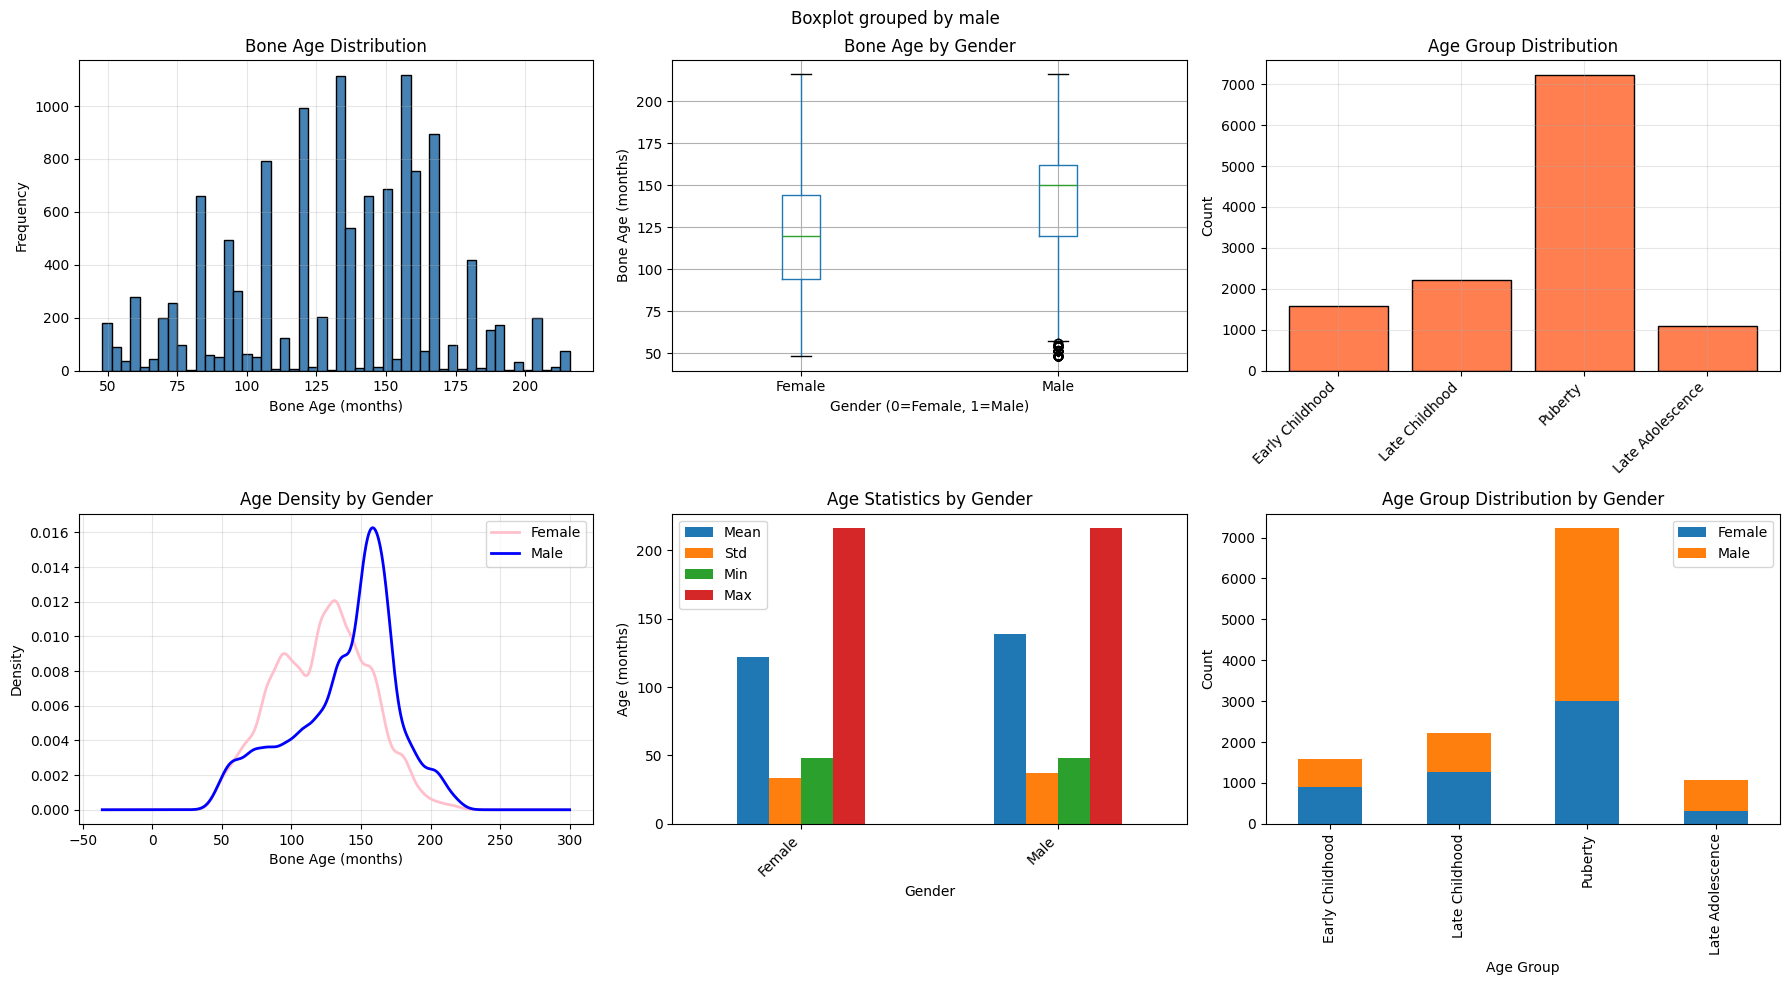

 Data exploration visualization saved


In [7]:
# Visualize data distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution
axes[0, 0].hist(train_df['boneage'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Bone Age (months)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Bone Age Distribution')
axes[0, 0].grid(alpha=0.3)

# Age by gender
train_df.boxplot(column='boneage', by='male', ax=axes[0, 1])
axes[0, 1].set_xlabel('Gender (0=Female, 1=Male)')
axes[0, 1].set_ylabel('Bone Age (months)')
axes[0, 1].set_title('Bone Age by Gender')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Female', 'Male'])

# Age group distribution
age_group_counts = train_df['age_group'].value_counts().sort_index()
labels = [CONFIG['age_groups'][i]['name'] for i in age_group_counts.index]
axes[0, 2].bar(range(len(labels)), age_group_counts.values, color='coral', edgecolor='black')
axes[0, 2].set_xticks(range(len(labels)))
axes[0, 2].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Age Group Distribution')
axes[0, 2].grid(alpha=0.3)

# KDE by gender
train_df[train_df['male']==0]['boneage'].plot(kind='density', ax=axes[1, 0], label='Female', color='pink', linewidth=2)
train_df[train_df['male']==1]['boneage'].plot(kind='density', ax=axes[1, 0], label='Male', color='blue', linewidth=2)
axes[1, 0].set_xlabel('Bone Age (months)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Age Density by Gender')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Age statistics by gender
age_stats = train_df.groupby('male')['boneage'].agg(['mean', 'std', 'min', 'max'])
age_stats.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Age (months)')
axes[1, 1].set_title('Age Statistics by Gender')
axes[1, 1].legend(['Mean', 'Std', 'Min', 'Max'])
plt.sca(axes[1, 1])
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)

# Age group by gender
age_group_gender = pd.crosstab(train_df['age_group'], train_df['male'])
age_group_gender.columns = ['Female', 'Male']
age_group_gender.index = [CONFIG['age_groups'][i]['name'] for i in age_group_gender.index]
age_group_gender.plot(kind='bar', ax=axes[1, 2], stacked=True)
axes[1, 2].set_xlabel('Age Group')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Age Group Distribution by Gender')
axes[1, 2].legend()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(IMAGE_DIR / '01_data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Data exploration visualization saved")

## 5. Sample Image Visualization

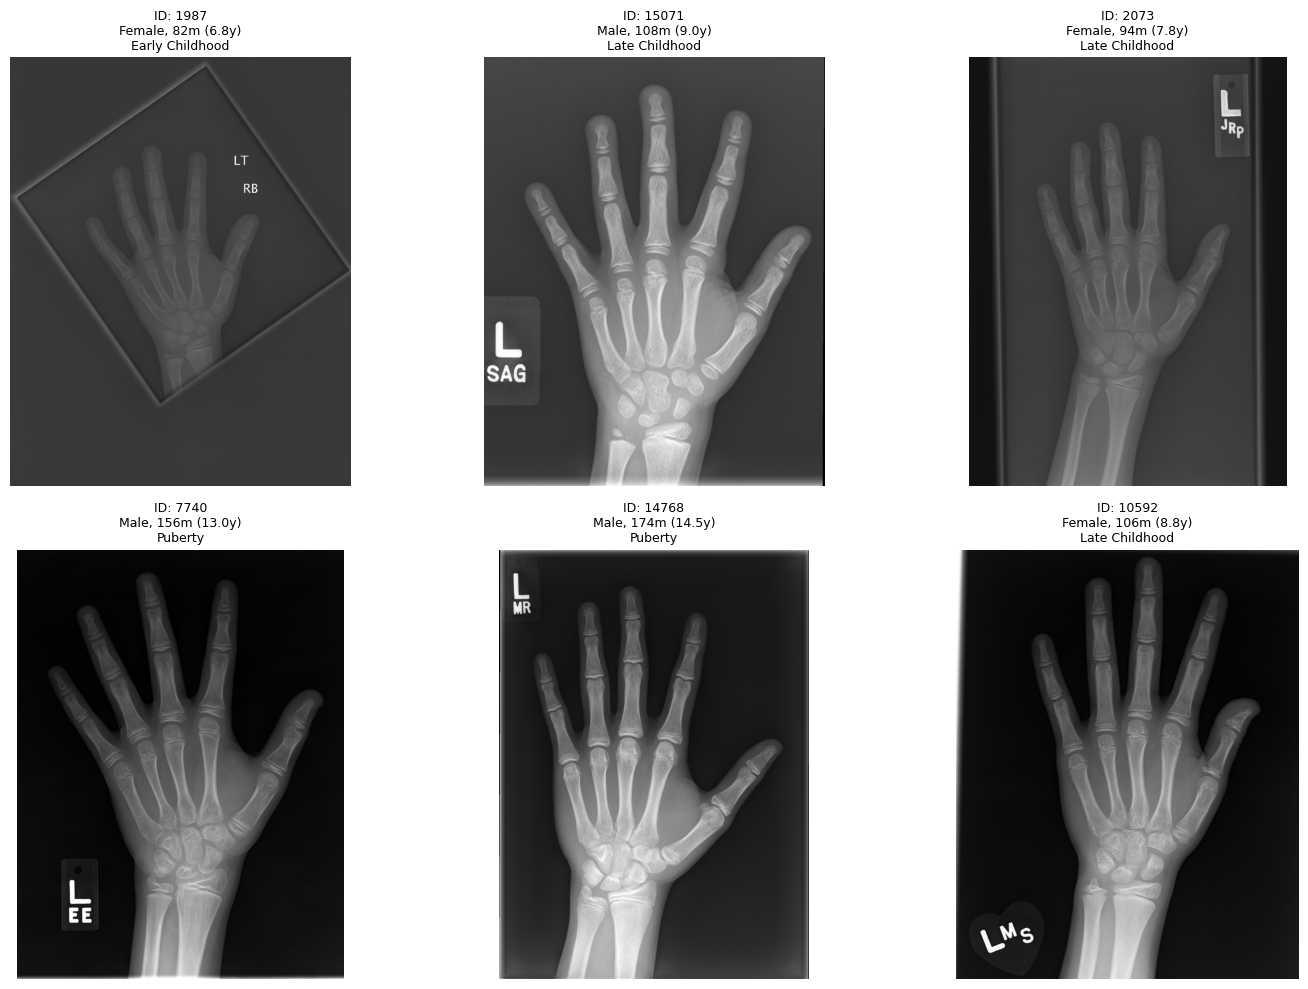

 Sample images saved


In [8]:
# Display sample images
sample_ids = train_df['id'].sample(6, random_state=42).values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, image_id in enumerate(sample_ids):
    row = idx // 3
    col = idx % 3
    
    image_path = train_images_dir / f'{image_id}.png'
    
    if image_path.exists():
        img = io.imread(image_path)
        
        row_data = train_df[train_df['id'] == image_id].iloc[0]
        age_months = row_data['boneage']
        age_years = row_data['age_years']
        gender = 'Male' if row_data['male'] else 'Female'
        age_group = CONFIG['age_groups'][row_data['age_group']]['name']
        
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(
            f'ID: {image_id}\n{gender}, {age_months}m ({age_years:.1f}y)\n{age_group}',
            fontsize=9
        )
        axes[row, col].axis('off')
    else:
        axes[row, col].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(IMAGE_DIR / '02_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Sample images saved")

## 6. Image Preprocessing Pipeline

### Preprocessing Steps:
1. Load grayscale X-ray image
2. Resize to 224x224 (ResNet-50 input)
3. Convert to RGB (3 channels)
4. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
5. Normalize using ResNet-50 preprocessing

In [9]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Preprocess X-ray image for ResNet-50 feature extraction.
    """
    # Load image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    
    # Resize
    img = img.resize(target_size)
    
    # Convert to array
    img_array = np.array(img)
    
    # Apply CLAHE for contrast enhancement
    img_array = exposure.equalize_adapthist(img_array, clip_limit=0.03)
    
    # Convert to RGB (duplicate channels)
    img_rgb = np.stack([img_array, img_array, img_array], axis=-1)
    
    # Normalize to [0, 255] for ResNet preprocessing
    img_rgb = (img_rgb * 255).astype(np.uint8)
    
    return img_rgb

# Test preprocessing
sample_path = train_images_dir / f"{train_df.iloc[0]['id']}.png"
if sample_path.exists():
    test_img = preprocess_image(sample_path)
    print(f"Preprocessed image shape: {test_img.shape}")
    print(f"Image dtype: {test_img.dtype}")
    print(f"Value range: [{test_img.min()}, {test_img.max()}]")
    print("Preprocessing pipeline verified")

Preprocessed image shape: (224, 224, 3)
Image dtype: uint8
Value range: [0, 255]
Preprocessing pipeline verified


## 7. Deep Feature Extraction using ResNet-50

### Transfer Learning Approach:
- Use ResNet-50 pretrained on ImageNet
- Extract features from the last pooling layer (2048 dimensions)
- Features serve as input to ML models

In [10]:
# Load ResNet-50 model (without top classification layer)
print("Loading ResNet-50 model...\n")

resnet_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'  # Global average pooling (2048 features)
)

print("ResNet-50 loaded successfully")
print(f"Output shape: {resnet_model.output_shape}")
print(f"Total parameters: {resnet_model.count_params():,}")

Loading ResNet-50 model...

ResNet-50 loaded successfully
Output shape: (None, 2048)
Total parameters: 23,587,712


In [11]:
def extract_features(image_path, model):
    """
    Extract deep features from X-ray image using ResNet-50.
    """
    # Preprocess image
    img = preprocess_image(image_path)
    
    # Expand dims for batch
    img = np.expand_dims(img, axis=0)
    
    # Apply ResNet-50 preprocessing
    img = preprocess_input(img)
    
    # Extract features
    features = model.predict(img, verbose=0)
    
    return features.flatten()

# Test feature extraction
if sample_path.exists():
    test_features = extract_features(sample_path, resnet_model)
    print(f"Extracted features shape: {test_features.shape}")
    print(f"Feature statistics:")
    print(f"  Mean: {test_features.mean():.4f}")
    print(f"  Std: {test_features.std():.4f}")
    print(f"  Min: {test_features.min():.4f}")
    print(f"  Max: {test_features.max():.4f}")
    print("Feature extraction verified")

Extracted features shape: (2048,)
Feature statistics:
  Mean: 0.4376
  Std: 0.7621
  Min: 0.0000
  Max: 9.1531
Feature extraction verified


## 8. Extract Features for All Images

In [12]:
# Check if features already extracted
features_file = MODEL_DIR / 'resnet50_features.npy'
labels_file = MODEL_DIR / 'labels.npy'

if features_file.exists() and labels_file.exists():
    print("Loading pre-extracted features...")
    X_features = np.load(features_file)
    y_regression = np.load(labels_file)
    y_classification = train_df['age_group'].values
    print(f"Loaded {len(X_features)} feature vectors")
else:
    print("Extracting features from all images...")
    print(f"Total images: {len(train_df)}\n")
    
    X_features = []
    y_regression = []
    y_classification = []
    
    for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Extracting features"):
        image_path = train_images_dir / f"{row['id']}.png"
        
        if image_path.exists():
            try:
                features = extract_features(image_path, resnet_model)
                X_features.append(features)
                y_regression.append(row['boneage'])
                y_classification.append(row['age_group'])
            except Exception as e:
                print(f"Error processing {row['id']}: {e}")
    
    # Convert to arrays
    X_features = np.array(X_features)
    y_regression = np.array(y_regression)
    y_classification = np.array(y_classification)
    
    # Save features
    np.save(features_file, X_features)
    np.save(labels_file, y_regression)
    
    print(f"\n eatures extracted and saved")
    print(f"Feature matrix shape: {X_features.shape}")
    print(f"Regression labels shape: {y_regression.shape}")
    print(f"Classification labels shape: {y_classification.shape}")

Extracting features from all images...
Total images: 12093



Extracting features: 100%|██████████| 12093/12093 [1:04:23<00:00,  3.13it/s]



 eatures extracted and saved
Feature matrix shape: (12093, 2048)
Regression labels shape: (12093,)
Classification labels shape: (12093,)


## 9. Data Splitting (Train/Validation/Test)

In [13]:
# Split data (stratified by age group)
X_train_val, X_test, y_reg_train_val, y_reg_test, y_cls_train_val, y_cls_test = train_test_split(
    X_features,
    y_regression,
    y_classification,
    test_size=CONFIG['test_split'],
    random_state=42,
    stratify=y_classification
)

# Split train/validation
val_ratio = CONFIG['validation_split'] / (1 - CONFIG['test_split'])
X_train, X_val, y_reg_train, y_reg_val, y_cls_train, y_cls_val = train_test_split(
    X_train_val,
    y_reg_train_val,
    y_cls_train_val,
    test_size=val_ratio,
    random_state=42,
    stratify=y_cls_train_val
)

print("Data Split:")
print(f"  Training: {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test: {len(X_test)} samples")
print(f"  Total: {len(X_features)} samples")

Data Split:
  Training: 8465 samples
  Validation: 1814 samples
  Test: 1814 samples
  Total: 12093 samples


## 10. Feature Scaling

In [14]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, MODEL_DIR / 'feature_scaler.pkl')

print("Features scaled and scaler saved")
print(f"Scaled feature statistics (train):")
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std: {X_train_scaled.std():.4f}")

Features scaled and scaler saved
Scaled feature statistics (train):
  Mean: -0.0000
  Std: 1.0000


## 11. Regression Model: Gradient Boosting Regressor

### Task: Predict continuous bone age in months

In [15]:
# Train Gradient Boosting Regressor
print("Training Gradient Boosting Regressor...\n")

gb_regressor = GradientBoostingRegressor(**CONFIG['gb_params'])
gb_regressor.fit(X_train_scaled, y_reg_train)

joblib.dump(gb_regressor, MODEL_DIR / 'gradient_boosting_regressor.pkl')

print("Gradient Boosting Regressor trained and saved")
print(f"Number of estimators: {gb_regressor.n_estimators}")
print(f"Max depth: {gb_regressor.max_depth}")

Training Gradient Boosting Regressor...

Gradient Boosting Regressor trained and saved
Number of estimators: 200
Max depth: 5


In [16]:
# Regression predictions
y_reg_train_pred = gb_regressor.predict(X_train_scaled)
y_reg_val_pred = gb_regressor.predict(X_val_scaled)
y_reg_test_pred = gb_regressor.predict(X_test_scaled)

# Calculate regression metrics
def calculate_regression_metrics(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Set - Regression Metrics:")
    print(f"  MAE: {mae:.2f} months ({mae/12:.2f} years)")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f} months ({rmse/12:.2f} years)")
    print(f"  R² Score: {r2:.4f}")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Evaluate on all sets
train_metrics = calculate_regression_metrics(y_reg_train, y_reg_train_pred, "Training")
val_metrics = calculate_regression_metrics(y_reg_val, y_reg_val_pred, "Validation")
test_metrics = calculate_regression_metrics(y_reg_test, y_reg_test_pred, "Test")


Training Set - Regression Metrics:
  MAE: 5.96 months (0.50 years)
  MSE: 54.97
  RMSE: 7.41 months (0.62 years)
  R² Score: 0.9593

Validation Set - Regression Metrics:
  MAE: 15.65 months (1.30 years)
  MSE: 396.40
  RMSE: 19.91 months (1.66 years)
  R² Score: 0.7020

Test Set - Regression Metrics:
  MAE: 15.83 months (1.32 years)
  MSE: 399.17
  RMSE: 19.98 months (1.66 years)
  R² Score: 0.7087


## 12. Classification Model: Support Vector Machine (SVM)

### Task: Classify age groups (4 classes)

In [17]:
# Train SVM Classifier
print("Training Support Vector Machine (SVM)...\n")

svm_classifier = SVC(**CONFIG['svm_params'])
svm_classifier.fit(X_train_scaled, y_cls_train)

# Save model
joblib.dump(svm_classifier, MODEL_DIR / 'svm_classifier.pkl')

print("SVM Classifier trained and saved")
print(f"Kernel: {svm_classifier.kernel}")
print(f"Number of support vectors: {len(svm_classifier.support_vectors_)}")

Training Support Vector Machine (SVM)...

SVM Classifier trained and saved
Kernel: rbf
Number of support vectors: 6941


In [18]:
# Classification predictions
y_cls_train_pred = svm_classifier.predict(X_train_scaled)
y_cls_val_pred = svm_classifier.predict(X_val_scaled)
y_cls_test_pred = svm_classifier.predict(X_test_scaled)

# Calculate classification metrics
def calculate_classification_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{dataset_name} Set - Classification Metrics:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  F1-Score (weighted): {f1:.4f}")
    
    # Classification report
    target_names = [CONFIG['age_groups'][i]['name'] for i in sorted(CONFIG['age_groups'].keys())]
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    return {'Accuracy': accuracy, 'F1-Score': f1}

# Evaluate on all sets
train_cls_metrics = calculate_classification_metrics(y_cls_train, y_cls_train_pred, "Training")
val_cls_metrics = calculate_classification_metrics(y_cls_val, y_cls_val_pred, "Validation")
test_cls_metrics = calculate_classification_metrics(y_cls_test, y_cls_test_pred, "Test")


Training Set - Classification Metrics:
  Accuracy: 1.0000 (100.00%)
  F1-Score (weighted): 1.0000

Classification Report:
                  precision    recall  f1-score   support

 Early Childhood       1.00      1.00      1.00      1102
  Late Childhood       1.00      1.00      1.00      1552
         Puberty       1.00      1.00      1.00      5057
Late Adolescence       1.00      1.00      1.00       754

        accuracy                           1.00      8465
       macro avg       1.00      1.00      1.00      8465
    weighted avg       1.00      1.00      1.00      8465


Validation Set - Classification Metrics:
  Accuracy: 0.7519 (75.19%)
  F1-Score (weighted): 0.7393

Classification Report:
                  precision    recall  f1-score   support

 Early Childhood       0.70      0.64      0.67       236
  Late Childhood       0.54      0.42      0.47       333
         Puberty       0.81      0.92      0.86      1083
Late Adolescence       0.68      0.48      0.57      

## 13. Regression Visualizations

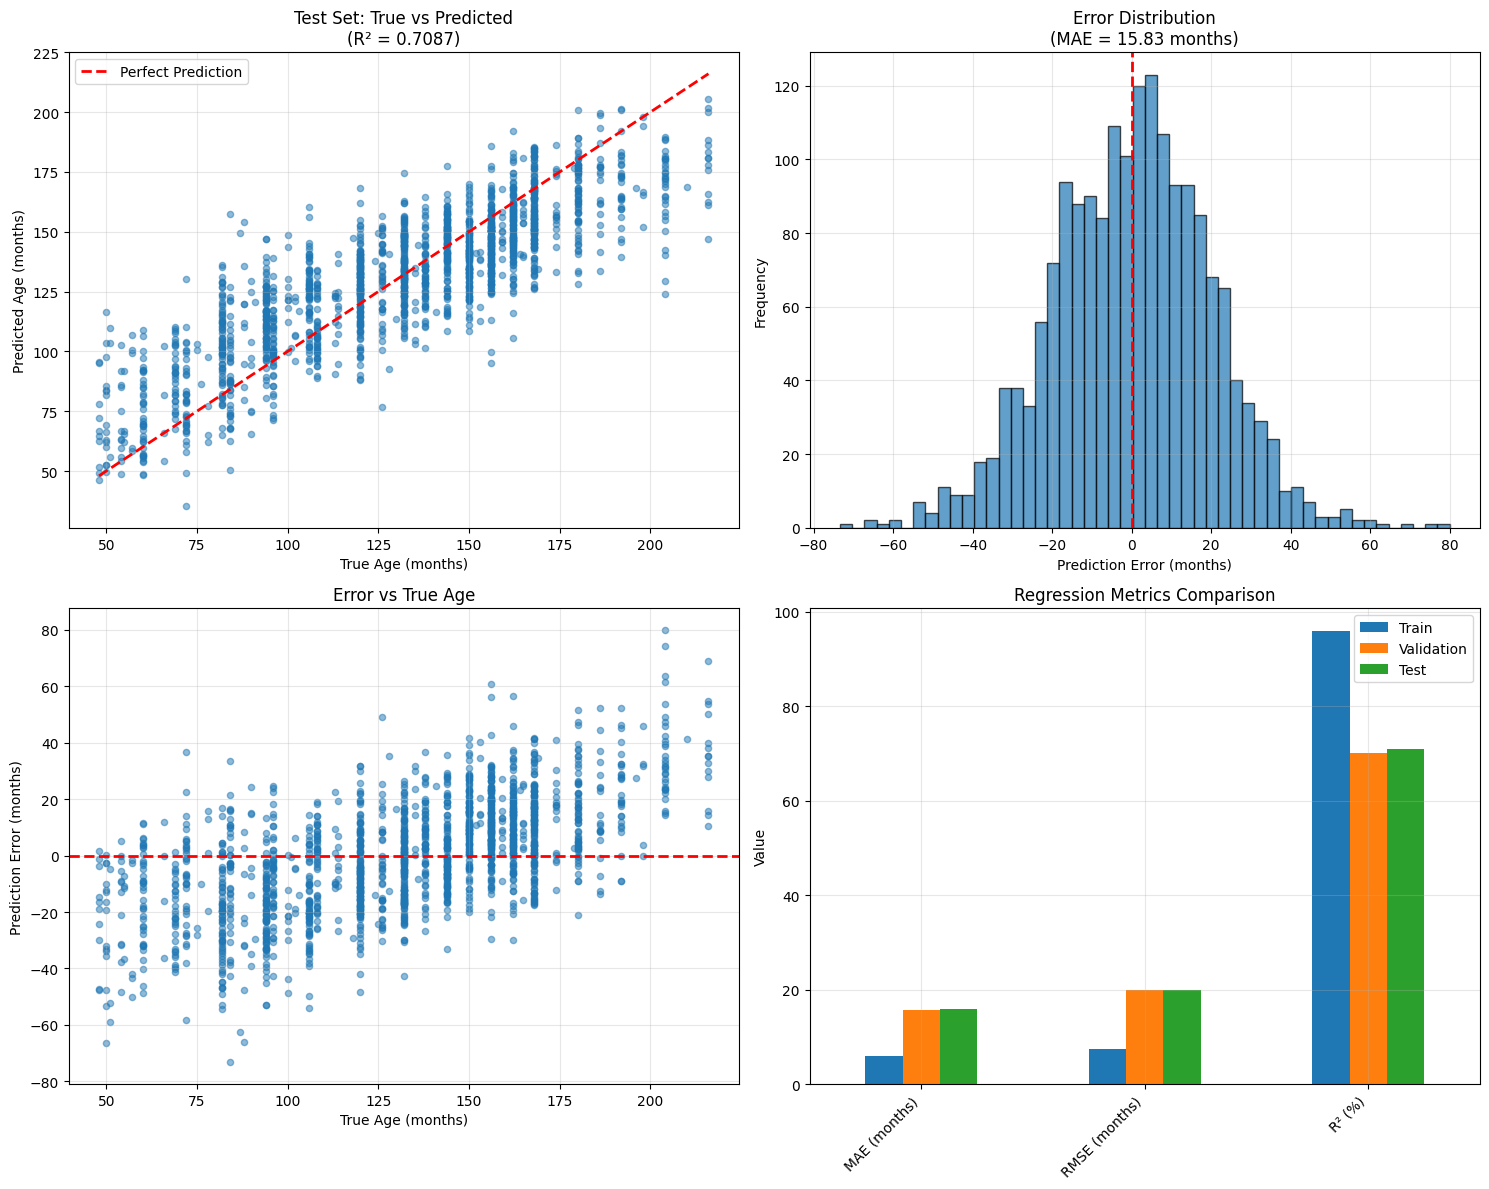

Regression visualizations saved


In [19]:
# Regression prediction analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# True vs Predicted (Test set)
axes[0, 0].scatter(y_reg_test, y_reg_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_reg_test.min(), y_reg_test.max()], 
                 [y_reg_test.min(), y_reg_test.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('True Age (months)')
axes[0, 0].set_ylabel('Predicted Age (months)')
axes[0, 0].set_title(f'Test Set: True vs Predicted\n(R² = {test_metrics["R2"]:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Error distribution
errors = y_reg_test - y_reg_test_pred
axes[0, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Prediction Error (months)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Error Distribution\n(MAE = {test_metrics["MAE"]:.2f} months)')
axes[0, 1].grid(alpha=0.3)

# Error vs True Age
axes[1, 0].scatter(y_reg_test, errors, alpha=0.5, s=20)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('True Age (months)')
axes[1, 0].set_ylabel('Prediction Error (months)')
axes[1, 0].set_title('Error vs True Age')
axes[1, 0].grid(alpha=0.3)

# Metrics comparison
metrics_df = pd.DataFrame({
    'Train': [train_metrics['MAE'], train_metrics['RMSE'], train_metrics['R2']*100],
    'Validation': [val_metrics['MAE'], val_metrics['RMSE'], val_metrics['R2']*100],
    'Test': [test_metrics['MAE'], test_metrics['RMSE'], test_metrics['R2']*100]
}, index=['MAE (months)', 'RMSE (months)', 'R² (%)'])

metrics_df.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Regression Metrics Comparison')
axes[1, 1].legend()
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGE_DIR / '03_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Regression visualizations saved")

## 14. Classification Visualizations

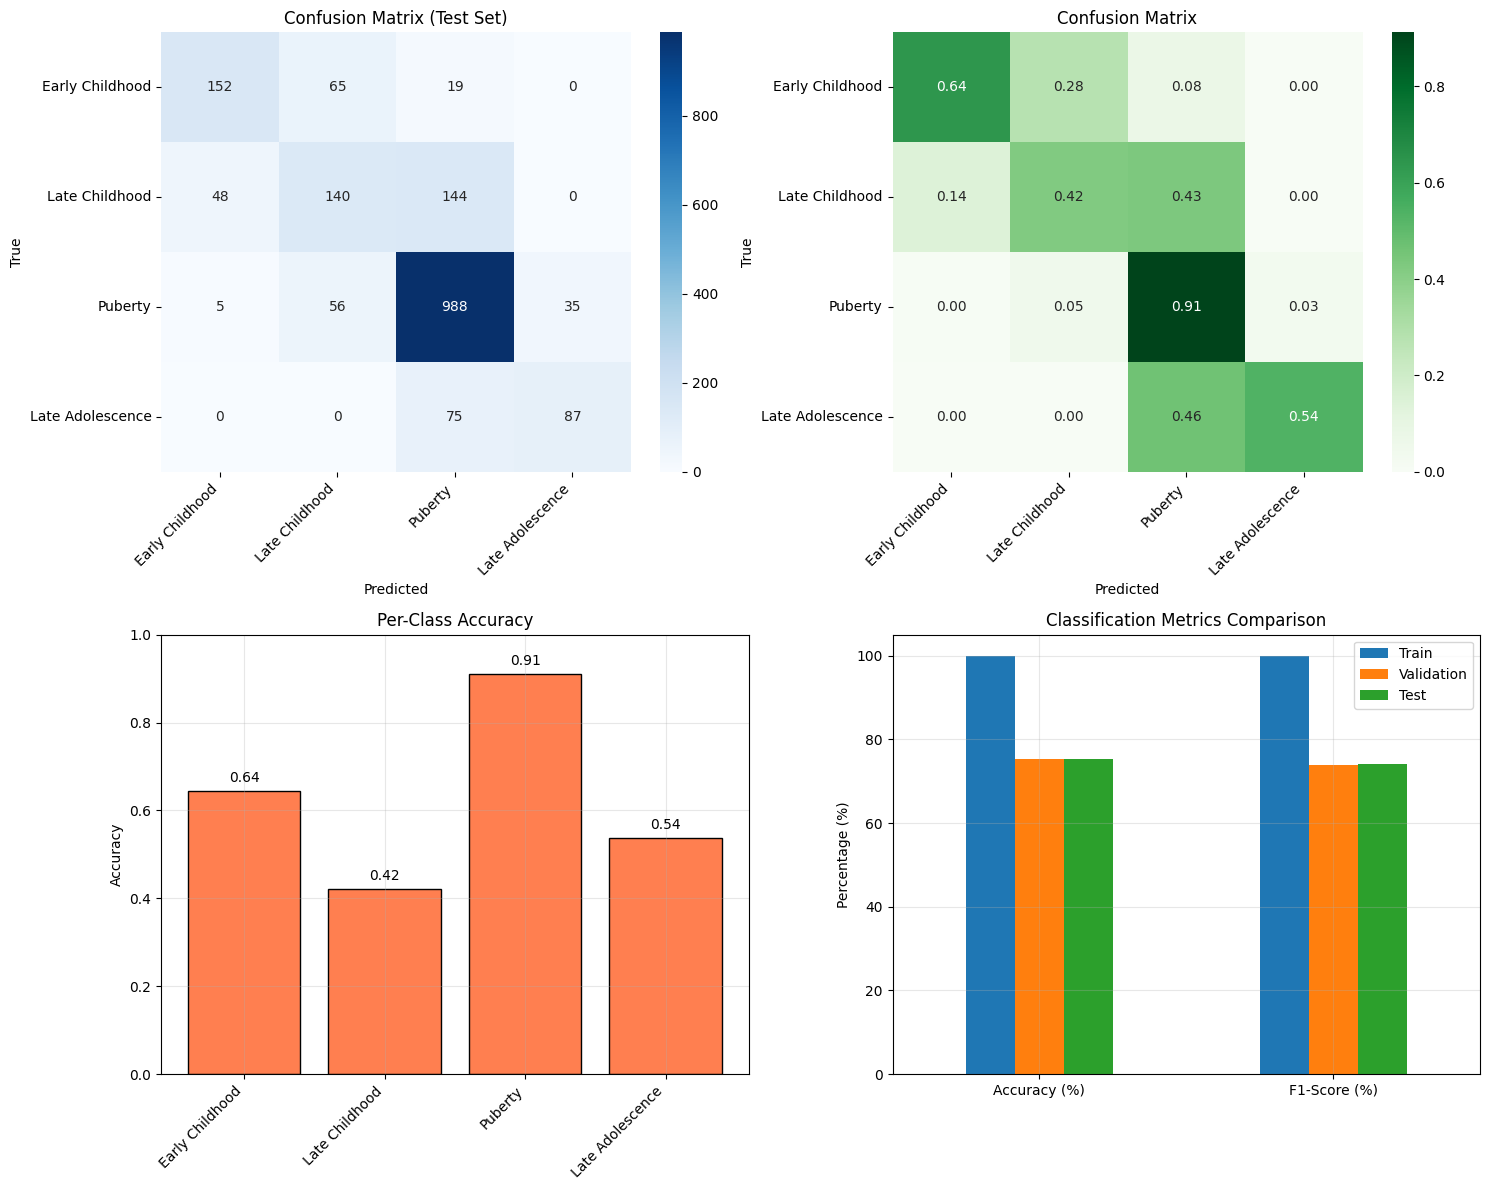

Classification visualizations saved


In [20]:
# Classification analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion Matrix (Test set)
cm = confusion_matrix(y_cls_test, y_cls_test_pred)
labels = [CONFIG['age_groups'][i]['name'] for i in sorted(CONFIG['age_groups'].keys())]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0, 0])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_title('Confusion Matrix (Test Set)')
plt.sca(axes[0, 0])
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('True')
axes[0, 1].set_title('Confusion Matrix')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Per-class accuracy
per_class_acc = cm_norm.diagonal()
axes[1, 0].bar(range(len(labels)), per_class_acc, color='coral', edgecolor='black')
axes[1, 0].set_xticks(range(len(labels)))
axes[1, 0].set_xticklabels(labels, rotation=45, ha='right')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Per-Class Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(alpha=0.3)

# Add accuracy values on bars
for i, acc in enumerate(per_class_acc):
    axes[1, 0].text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=10)

# Accuracy & F1-Score comparison
cls_metrics_df = pd.DataFrame({
    'Train': [train_cls_metrics['Accuracy']*100, train_cls_metrics['F1-Score']*100],
    'Validation': [val_cls_metrics['Accuracy']*100, val_cls_metrics['F1-Score']*100],
    'Test': [test_cls_metrics['Accuracy']*100, test_cls_metrics['F1-Score']*100]
}, index=['Accuracy (%)', 'F1-Score (%)'])

cls_metrics_df.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Classification Metrics Comparison')
axes[1, 1].legend()
plt.sca(axes[1, 1])
plt.xticks(rotation=0)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGE_DIR / '04_classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Classification visualizations saved")

## 15. Sample Predictions Visualization

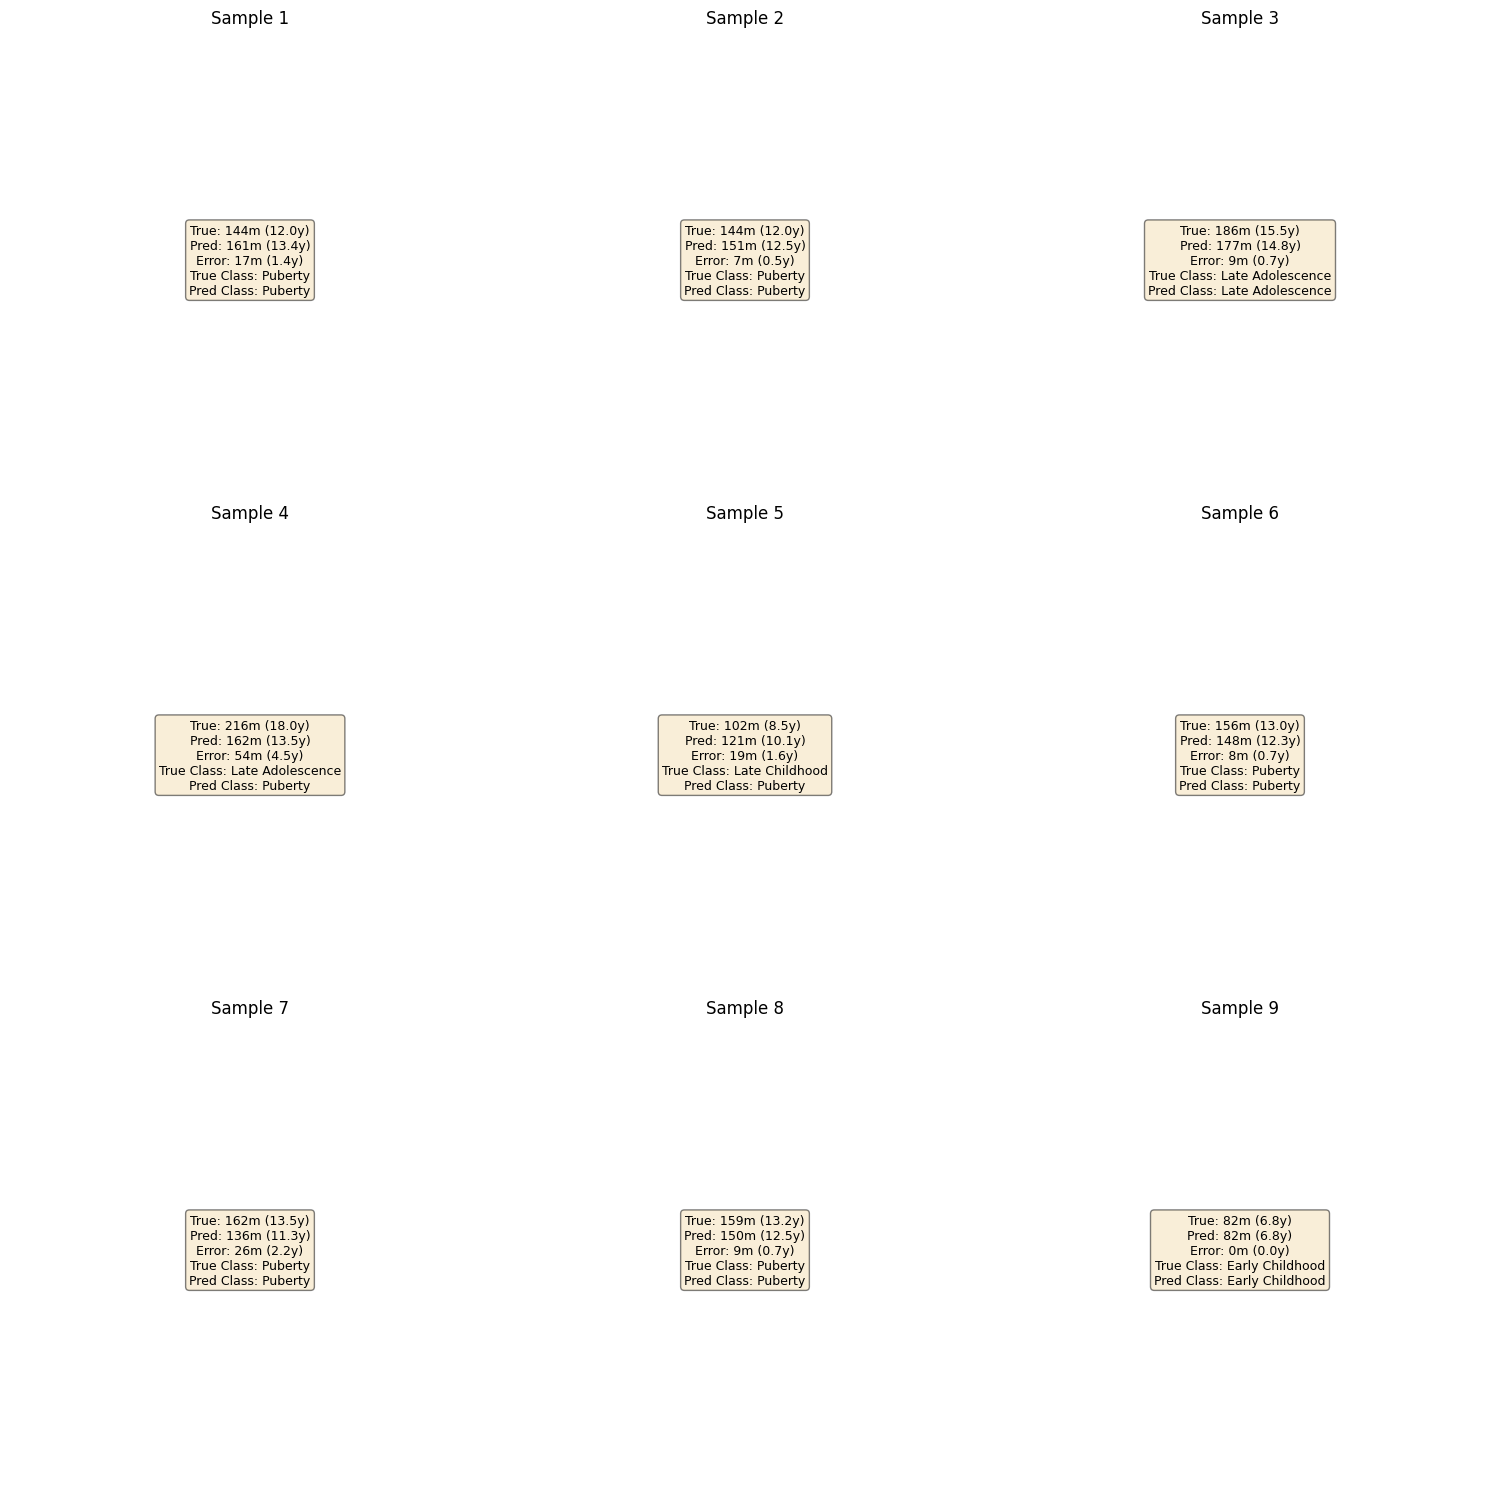

Sample predictions visualized


In [21]:
# Select random test samples
n_samples = 9
sample_indices = np.random.choice(len(X_test), size=n_samples, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx, sample_idx in enumerate(sample_indices):
    row = idx // 3
    col = idx % 3
    
    # Get predictions
    true_age = y_reg_test[sample_idx]
    pred_age = y_reg_test_pred[sample_idx]
    true_class = y_cls_test[sample_idx]
    pred_class = y_cls_test_pred[sample_idx]
    
    error = abs(true_age - pred_age)
    
    # Find corresponding image
    # (This is approximate - you may need to track image IDs)
    info_text = f"True: {true_age:.0f}m ({true_age/12:.1f}y)\n"
    info_text += f"Pred: {pred_age:.0f}m ({pred_age/12:.1f}y)\n"
    info_text += f"Error: {error:.0f}m ({error/12:.1f}y)\n"
    info_text += f"True Class: {CONFIG['age_groups'][true_class]['name']}\n"
    info_text += f"Pred Class: {CONFIG['age_groups'][pred_class]['name']}"
    
    # Create placeholder visualization
    axes[row, col].text(0.5, 0.5, info_text, 
                        ha='center', va='center',
                        fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[row, col].set_title(f'Sample {idx+1}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(IMAGE_DIR / '05_sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sample predictions visualized")

## 16. Performance Summary Report

In [22]:
# Generate comprehensive report
report = f"""
{'='*80}
BONE AGE PREDICTION SYSTEM - PERFORMANCE SUMMARY
FYP PROJECT: KMK3103/3104 (Semester 2, 2025/2026)
{'='*80}

METHODOLOGY:
  • Feature Extraction: ResNet-50 (ImageNet pretrained)
  • Regression Model: Gradient Boosting Regressor
  • Classification Model: Support Vector Machine (SVM)
  • Image Size: {CONFIG['image_size']}
  • Feature Dimensions: 2048 (ResNet-50 output)

DATASET:
  • Source: RSNA 2017 Pediatric Bone Age
  • Method: Greulich & Pyle (GP) Atlas
  • Total Samples: {len(X_features):,}
  • Training: {len(X_train):,}
  • Validation: {len(X_val):,}
  • Test: {len(X_test):,}

AGE GROUPS:
"""

for group_id, info in CONFIG['age_groups'].items():
    count = (y_classification == group_id).sum()
    report += f"  Class {group_id} - {info['name']} ({info['range'][0]}-{info['range'][1]} years): {count:,} samples\n"

report += f"""
REGRESSION PERFORMANCE (Bone Age in Months):
  Test Set:
    • MAE: {test_metrics['MAE']:.2f} months ({test_metrics['MAE']/12:.2f} years)
    • MSE: {test_metrics['MSE']:.2f}
    • RMSE: {test_metrics['RMSE']:.2f} months ({test_metrics['RMSE']/12:.2f} years)
    • R² Score: {test_metrics['R2']:.4f}
  
  Validation Set:
    • MAE: {val_metrics['MAE']:.2f} months ({val_metrics['MAE']/12:.2f} years)
    • RMSE: {val_metrics['RMSE']:.2f} months ({val_metrics['RMSE']/12:.2f} years)
    • R² Score: {val_metrics['R2']:.4f}

CLASSIFICATION PERFORMANCE (Age Group):
  Test Set:
    • Accuracy: {test_cls_metrics['Accuracy']:.4f} ({test_cls_metrics['Accuracy']*100:.2f}%)
    • F1-Score (weighted): {test_cls_metrics['F1-Score']:.4f}
  
  Validation Set:
    • Accuracy: {val_cls_metrics['Accuracy']:.4f} ({val_cls_metrics['Accuracy']*100:.2f}%)
    • F1-Score (weighted): {val_cls_metrics['F1-Score']:.4f}

ERROR ANALYSIS:
  • Mean Error: {errors.mean():.2f} months
  • Std Error: {errors.std():.2f} months
  • Median Absolute Error: {np.median(np.abs(errors)):.2f} months
  • 90th Percentile Error: {np.percentile(np.abs(errors), 90):.2f} months
  • Predictions within ±12 months: {(np.abs(errors) <= 12).sum() / len(errors) * 100:.1f}%
  • Predictions within ±24 months: {(np.abs(errors) <= 24).sum() / len(errors) * 100:.1f}%

MODEL FILES:
  • ResNet-50 Features: {features_file}
  • Gradient Boosting Regressor: {MODEL_DIR / 'gradient_boosting_regressor.pkl'}
  • SVM Classifier: {MODEL_DIR / 'svm_classifier.pkl'}
  • Feature Scaler: {MODEL_DIR / 'feature_scaler.pkl'}
  • Visualizations: {IMAGE_DIR}

COMPARISON WITH LITERATURE:
  • Target MAE (2026 SOTA): 0.25-0.30 years
  • Our MAE: {test_metrics['MAE']/12:.2f} years
  • Status: {'Achieved' if test_metrics['MAE']/12 <= 0.35 else 'Needs improvement'}

{'='*80}
"""

print(report)

# Save report
with open(MODEL_DIR / 'performance_report.txt', 'w') as f:
    f.write(report)

print("Performance report saved")


BONE AGE PREDICTION SYSTEM - PERFORMANCE SUMMARY
FYP PROJECT: KMK3103/3104 (Semester 2, 2025/2026)

METHODOLOGY:
  • Feature Extraction: ResNet-50 (ImageNet pretrained)
  • Regression Model: Gradient Boosting Regressor
  • Classification Model: Support Vector Machine (SVM)
  • Image Size: (224, 224)
  • Feature Dimensions: 2048 (ResNet-50 output)

DATASET:
  • Source: RSNA 2017 Pediatric Bone Age
  • Method: Greulich & Pyle (GP) Atlas
  • Total Samples: 12,093
  • Training: 8,465
  • Validation: 1,814
  • Test: 1,814

AGE GROUPS:
  Class 0 - Early Childhood (4-6 years): 1,574 samples
  Class 1 - Late Childhood (7-9 years): 2,217 samples
  Class 2 - Puberty (10-14 years): 7,224 samples
  Class 3 - Late Adolescence (15-18 years): 1,078 samples

REGRESSION PERFORMANCE (Bone Age in Months):
  Test Set:
    • MAE: 15.83 months (1.32 years)
    • MSE: 399.17
    • RMSE: 19.98 months (1.66 years)
    • R² Score: 0.7087
  
  Validation Set:
    • MAE: 15.65 months (1.30 years)
    • RMSE: 19.

## 17. Model Export and Inference Functions

In [23]:
# Save model configuration
config_export = {
    'image_size': CONFIG['image_size'],
    'feature_dim': 2048,
    'age_groups': CONFIG['age_groups'],
    'gb_params': CONFIG['gb_params'],
    'svm_params': CONFIG['svm_params'],
    'test_metrics': {
        'regression': test_metrics,
        'classification': test_cls_metrics
    }
}

with open(MODEL_DIR / 'model_config.json', 'w') as f:
    json.dump(config_export, f, indent=2, default=str)

print("Model configuration saved")

# Create inference function
def predict_bone_age(image_path, resnet_model, gb_regressor, svm_classifier, scaler):
    """
    Predict bone age and age group from X-ray image.
    
    Args:
        image_path: Path to X-ray image
        resnet_model: ResNet-50 feature extractor
        gb_regressor: Gradient Boosting Regressor
        svm_classifier: SVM Classifier
        scaler: Feature scaler
    
    Returns:
        Dictionary with predictions
    """
    # Extract features
    features = extract_features(image_path, resnet_model)
    features_scaled = scaler.transform(features.reshape(1, -1))
    
    # Predict age
    age_months = gb_regressor.predict(features_scaled)[0]
    age_years = age_months / 12
    
    # Predict age group
    age_group_id = svm_classifier.predict(features_scaled)[0]
    age_group_name = CONFIG['age_groups'][age_group_id]['name']
    
    return {
        'age_months': age_months,
        'age_years': age_years,
        'age_group_id': age_group_id,
        'age_group_name': age_group_name
    }

print("Inference function defined")

Model configuration saved
Inference function defined


## 18. Inference Example

In [24]:
# Test inference on sample
print("\nINFERENCE EXAMPLE:")
print("="*60)

sample_row = train_df.iloc[0]
sample_path = train_images_dir / f"{sample_row['id']}.png"

if sample_path.exists():
    # Predict
    result = predict_bone_age(
        sample_path,
        resnet_model,
        gb_regressor,
        svm_classifier,
        scaler
    )
    
    print(f"Image ID: {sample_row['id']}")
    print(f"Gender: {'Male' if sample_row['male'] else 'Female'}")
    print(f"\nTrue Age: {sample_row['boneage']:.0f} months ({sample_row['age_years']:.2f} years)")
    print(f"Predicted Age: {result['age_months']:.0f} months ({result['age_years']:.2f} years)")
    print(f"Error: {abs(sample_row['boneage'] - result['age_months']):.0f} months")
    print(f"\nTrue Age Group: {CONFIG['age_groups'][sample_row['age_group']]['name']}")
    print(f"Predicted Age Group: {result['age_group_name']}")
else:
    print("Sample image not found")

print("="*60)
print("\n Inference example completed")


INFERENCE EXAMPLE:
Image ID: 1377
Gender: Female

True Age: 180 months (15.00 years)
Predicted Age: 181 months (15.12 years)
Error: 1 months

True Age Group: Late Adolescence
Predicted Age Group: Late Adolescence

 Inference example completed
